<a href="https://colab.research.google.com/github/zeynep-serra/ML_Notes/blob/main/Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
data = pd.read_csv('salary_data.csv')
X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
from sklearn.metrics import r2_score

0.9024461774180497


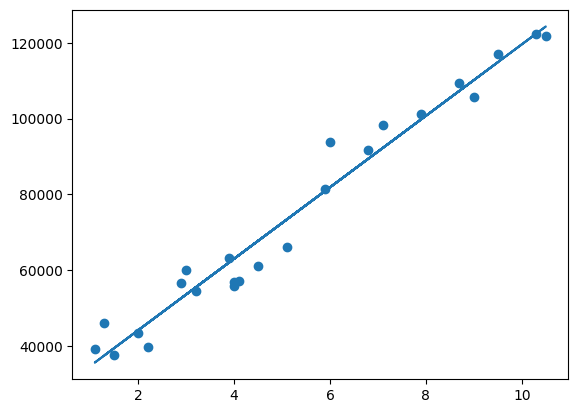

In [ ]:
# regression - to predict continuous value
# classification - to predict categorical value

# simple linear regression
# yhat = b0 + b1x1
# dependent var yhat = y-intercept constant b0 + slope coefficient b1 x independent var x1

# ordinary least squares: residual is diff betw real val and predicted val
# best line is: sum of squared residuals is minimized

# salary data dataset - years experience and salary

from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(X_train, y_train)

y_pred = regressor.predict(X_test)

print(r2_score(y_test, y_pred))

# training set
plt.scatter(X_train, y_train)
plt.plot(X_train, regressor.predict(X_train)) # regression line

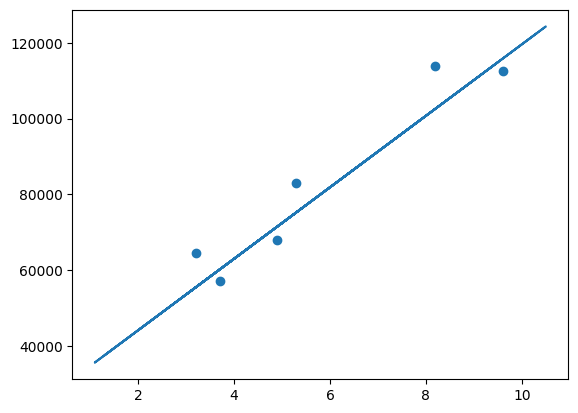

In [ ]:
# test set
plt.scatter(X_test, y_test)
plt.plot(X_train, regressor.predict(X_train)) # regression line is the same

In [ ]:
regressor.coef_, regressor.intercept_
# Salary = coef_ × YearsExperience + intercept_

(array([9423.81532303]), np.float64(25321.583011776813))

In [ ]:
# linear regression
# 1. linearity (linear rel)
# 2. homoscedasticity (equal variance, no cone shape)
# 3. multivariate normality (normality of err distribution)
# 4. independence (no autocorrelation, no patterns)
# 5. lack of multicollinearity (predictors are not correlated w each other)
# 6. outlier check

# categorical vars like state, create dummy vars
# use (state - 1) dummy vars
# if you include all dummy vars, for example 2
# D2 = 1 - D1 (multicollinearity) dummy var trap
# always dump 1 dummy var

# p-value (probability value)
# statistical significance alpha = 0.05 -> it is unlikely, reject the null hypothesis
# confidence level

# methods to build a model

# all-in: prior knowledge / preparing for backward elim.

# *** fastest and the one we use ***
# backward elim: select significance level, fit the model
# consider predictor w highest p val, if p>sl remove the predictor
# then refit the model

# forward selection: select significance level, fit all simple regr. models
# select the one w lowest p val, keep this
# then fit all models w one extra predictor on top of what u already have
# consider the predictor w lowest p val
# we keep growing the model by selecting from all the possible combinations
# at the end keep the prev model

# bidirectional elim (step-wise regr.): select 2 sl: enter / stay
# perform next step of forward selection (p < sl enter)
# perform all steps of backward elim. (p < sl stay)
# iterative process

0.8987266414319133


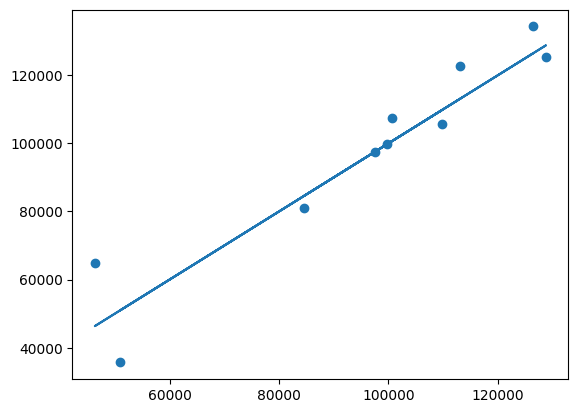

In [ ]:
data = pd.read_csv('startups.csv')
X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(), [3])],
                       remainder='passthrough')
X = ct.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# multiple linear regression automatically avoid dummy var trap
# multiple linear regression automatically identifies best features w highest p vals
# multiple independent vars
regressor = LinearRegression()
regressor.fit(X_train, y_train)

y_pred = regressor.predict(X_test)

print(r2_score(y_test, y_pred))

plt.scatter(y_pred, y_test)
plt.plot(y_pred, y_pred)

0.9162082221443942


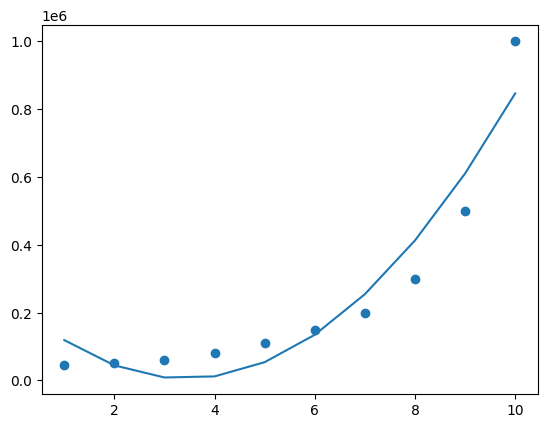

In [ ]:
# polynomial linear regression
# y = b0 + b1x1 + b2(x1^2)
data = pd.read_csv('salaries.csv')
X = data.iloc[:, 1:-1].values
y = data.iloc[:, -1].values
from sklearn.preprocessing import PolynomialFeatures
poly_reg = PolynomialFeatures(degree=2)
X_poly = poly_reg.fit_transform(X)
lin_reg = LinearRegression()
lin_reg.fit(X_poly, y)
plt.scatter(X, y)
plt.plot(X, lin_reg.predict(X_poly))

print(r2_score(y, lin_reg.predict(X_poly)))

0.9812097727913366


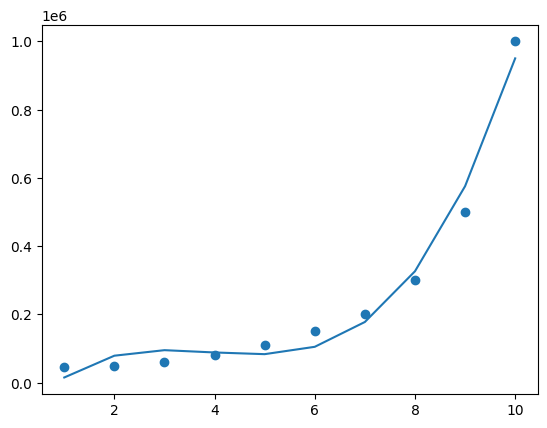

In [ ]:
poly_reg = PolynomialFeatures(degree=3)
X_poly = poly_reg.fit_transform(X)
lin_reg = LinearRegression()
lin_reg.fit(X_poly, y)
plt.scatter(X, y)
plt.plot(X, lin_reg.predict(X_poly))

print(r2_score(y, lin_reg.predict(X_poly)))

0.9973922891706614


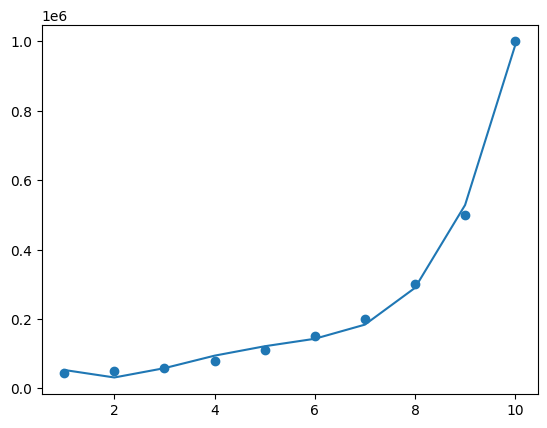

In [ ]:
# overfitting
poly_reg = PolynomialFeatures(degree=4)
X_poly = poly_reg.fit_transform(X)
lin_reg = LinearRegression()
lin_reg.fit(X_poly, y)
plt.scatter(X, y)
plt.plot(X, lin_reg.predict(X_poly))

print(r2_score(y, lin_reg.predict(X_poly)))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


0.7516001070620798


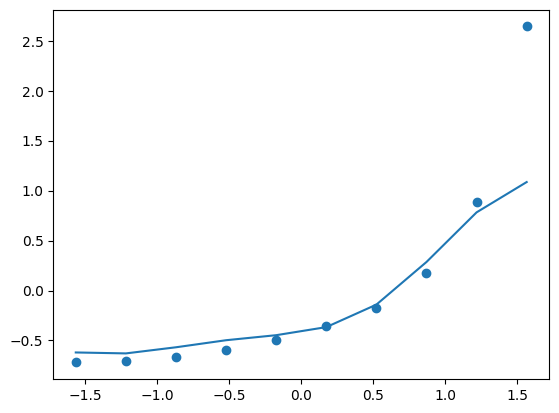

In [ ]:
# svr - support vector machine
# linear support vector regression
# tube instead of line (epsilon-insensitive tube)
# margin of err. - we do not care abt err inside the tube
# slack vars, points outside the tube, we care abt their err

# implicit equation / rel. we apply feature scaling
from sklearn.preprocessing import StandardScaler
scaler_x = StandardScaler()
X = scaler_x.fit_transform(X)

y = y.reshape(len(y), 1)
scaler_y = StandardScaler()
y = scaler_y.fit_transform(y)

from sklearn.svm import SVR
regressor = SVR()
# kernel (def rbf: radial basis func, gaussian rbf)
# linear, poly, sigmoid, precomputed
regressor.fit(X, y)
plt.scatter(X, y)
plt.plot(X, regressor.predict(X))

print(r2_score(y, regressor.predict(X)))

/tmp/ipython-input-971720433.py:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X_grid = np.arange(min(X), max(X), 0.1)


1.0


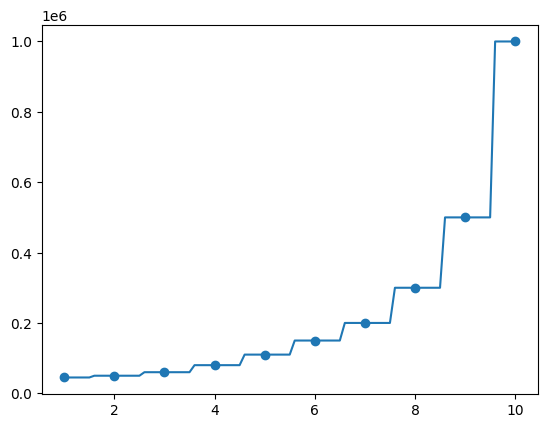

In [ ]:
# decision tree
# cart = classification and regression trees
# split into segments, terminal leaves
X = data.iloc[:, 1:-1].values
y = data.iloc[:, -1].values
# do not apply feature scaling
from sklearn.tree import DecisionTreeRegressor
regressor = DecisionTreeRegressor()
regressor.fit(X, y)

X_grid = np.arange(min(X), max(X), 0.1)
X_grid = X_grid.reshape(len(X_grid), 1)
plt.scatter(X, y)
plt.plot(X_grid, regressor.predict(X_grid))

print(r2_score(y, regressor.predict(X)))

/tmp/ipython-input-3313919625.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X_grid = np.arange(min(X), max(X), 0.1)


0.9678088294090482


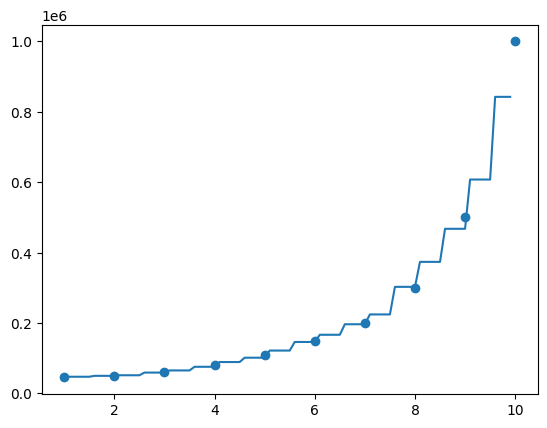

In [ ]:
# random forest - ensemble learning (put algo.s on top of each other)
from sklearn.ensemble import RandomForestRegressor
regressor = RandomForestRegressor()
# n_estimators, def=100
regressor.fit(X, y)

X_grid = np.arange(min(X), max(X), 0.1)
X_grid = X_grid.reshape(len(X_grid), 1)
plt.scatter(X, y)
plt.plot(X_grid, regressor.predict(X_grid))
# more steps

print(r2_score(y, regressor.predict(X)))

In [ ]:
# r squared
# ordinary least squares = residual sum of squares = SSres
# avg line of real y vals, SStot = total sum of squares

# goodness of fit
# r^2 = 1 - SSres / SStot
# 1 = perfect fit & sus
# 0.9 = very good
# 0.7 = decent
# <0.4 = poor fit

# adjusted r squared
# k - num of independent vars
# n - sample size
# this formula penalizes us for adding additional vars